In [1]:
## Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import pathlib
import json
from PIL import Image
from tensorflow.keras.layers import Conv2D, BatchNormalization, Dense,Input
from tensorflow.keras import Sequential
from pathlib import Path

## Load Images
image_dir='Normal_Images'
image_files_raw=sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg','jpeg', '.png', '.bmp'))])

image_files_full_path=[]
for i in image_files_raw:
    image_files_full_path.append(image_dir+'\\'+i)

## Read Images
images=[]
for i in image_files_full_path:
    images.append(cv2.imread(str(i)))

## Downsampling from 416 to 320
resized_images=[]
size=[(320,320)]
for img in images:
    #print(np.array(img))
    resized_images.append(cv2.resize(img,(320,320)))

## Normalie images
for i in range(len(resized_images)):
    resized_images[i]=np.round(resized_images[i]/255.0,2)

In [2]:
## Generating Y true
binary_images=[]
for image in resized_images:
    column=[]
    for i in range(image.shape[0]):
        row=[]
        for j in range(image.shape[1]):
            #print(np.mean(array_orig[i,j,:]))
            pixel=np.mean(image[i,j,:])
            if pixel>=0.6:
                pixel=1
            else:
                pixel=0

            row.append(pixel)
        column.append(row)
        
    binary_images.append(column)

## Train Test Split 
train_images=resized_images[:int(len(resized_images)*0.8)]
test_images=resized_images[int(len(resized_images)*0.8):]
y_train=binary_images[:int(len(resized_images)*0.8)]
y_test=binary_images[int(len(resized_images)*0.8):]

## To numpy array
train_images=np.array(train_images)
test_images=np.array(test_images)
y_train=np.array(y_train)
y_test=np.array(y_test)

c:\Users\HP\.pyenv\pyenv-win\versions\3.9.13\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 320, 320, 1)    │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7683 - loss: 0.4905 - mae: 0.3649 - mse: 0.1590 - val_accuracy: 0.8942 - val_loss: 0.2581 - val_mae: 0.2025 - val_mse: 0.0732
Epoch 2/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9641 - loss: 0.1979 - mae: 0.1635 - mse: 0.0491 - val_accuracy: 0.9826 - val_loss: 0.1789 - val_mae: 0.1481 - val_mse: 0.0451
Epoch 3/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9860 - loss: 0.1445 - mae: 0.1206 - mse: 0.0350 - val_accuracy: 0.9874 - val_loss: 0.1495 - val_mae: 0.1243 - val_mse: 0.0371
Epoch 4/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9912 - loss: 0.1190 - mae: 0.1000 - mse: 0.0281 - val_accuracy: 0.9863 - val_loss: 0.1316 - val_mae: 0.1095 - val_mse: 0.0325
Epoch 5/200
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9873 - loss: 0.1032 - mae: 0.0865 - mse: 0.0244 - val_accuracy: 0.9902 - val_loss: 0.1188 - val_mae: 0.0991 - val_mse: 0.0291
Epoch 6/200
90/90 ━━━━━━━━━━━━━━━━━

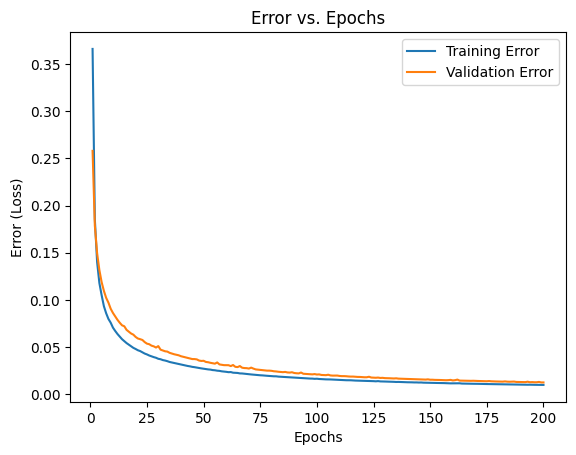

In [3]:
## One convolution approach
input_shape=(320,320,3)

## Model Architecture
model=Sequential([
    Conv2D(1,1,input_shape=(320,320,3),activation='sigmoid')
])

## Model Summary
print(model.summary())

## Setting optimiser and learning rate=0.1
from tensorflow.keras.optimizers import Adam
optimizer=Adam(learning_rate=0.1)
model.compile(optimizer=optimizer, loss='binary_crossentropy',metrics=['accuracy','mse','mae'])

## Training with 200 epochs
history = model.fit(train_images, y_train, validation_data=(test_images, y_test), epochs=200,batch_size=2)


# 2. Extract loss data
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# 3. Create the plot
plt.plot(epochs, train_loss , label='Training Error')
plt.plot(epochs, val_loss, label='Validation Error')
plt.title('Error vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Error (Loss)')
plt.legend()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


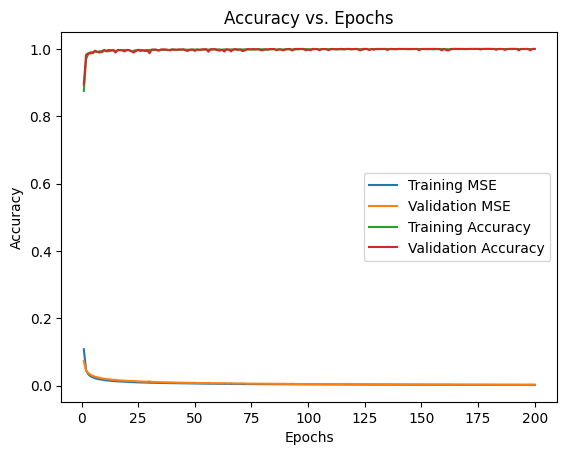

In [4]:
## Extract MSE
train_loss = history.history['mse']
val_loss = history.history['val_mse']
epochs = range(1, len(train_loss) + 1)

#Create the plot
plt.plot(epochs, train_loss , label='Training MSE')
plt.plot(epochs, val_loss, label='Validation MSE')
plt.title('MSE vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()

## Extract Accuracy
train_loss = history.history['accuracy']
val_loss = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

# 3. Create the plot
plt.plot(epochs, train_loss , label='Training Accuracy')
plt.plot(epochs, val_loss, label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()    

## Prediction
pred_images=model.predict(test_images)
pred_images.shape

## Converting back 0-255 levels
pred_images=pred_images*255.0

## Show image y_true and predicted
Image.fromarray((y_test[5]*255).astype(np.uint8)).show()
Image.fromarray(np.squeeze(pred_images[5]).astype(np.uint8)).show()

## Save Model
model.save('binary.h5')

In [5]:


## Loading Images from dir
image_dir='dip'
image_files_raw=sorted([f for f in os.listdir(image_dir) if f.lower().endswith(('.jpg','jpeg', '.png', '.bmp'))])

image_files_full_path=[]
for i in image_files_raw:
    image_files_full_path.append(image_dir+'\\'+i)

## Reading Images
images=[]
for i in image_files_full_path:
    images.append(cv2.imread(str(i)))

## Printing length of images
print(f'No. of Images: {len(images)}')

## Downsampling from 416 to 320
resized_val_images=[]
size=[(320,320)]
for img in images:
    #print(np.array(img))
    resized_val_images.append(cv2.resize(img,(320,320)))


No. of Images: 29


In [6]:
temp=resized_val_images.copy()

In [7]:

## Normalie images
for i in range(len(resized_val_images)):
    resized_val_images[i]=np.round(resized_val_images[i]/255.0,2)




In [8]:
resized_val_images=np.array(resized_val_images)

In [9]:
## Prediction
pred_images=model.predict(resized_val_images)
pred_images.shape

## Converting back to 0-255 levels
pred_images=pred_images*255.0
pred_images=pred_images.astype(int)

## Converting test images back to 0-255 levels
resized_val_images=resized_val_images*255.0
resized_val_images=resized_val_images.astype(int)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step


In [17]:
## Original Image
#Image.fromarray(temp[5].astype(np.uint8)).show()

## Predicted Image
Image.fromarray(np.squeeze(pred_images[11]).astype(np.uint8)).show()
i=Image.fromarray(np.squeeze(pred_images[11]).astype(np.uint8))
i.save('binary predicted.png')